# Comparative Transcriptomics

This notebook tracks the comparative analysis workflow for the rhythmic gene comparison project.

In [187]:
from pathlib import Path
import sys

def find_project_root(marker=".git"):
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / marker).exists():
            return candidate
    raise FileNotFoundError(f"Could not find project root (looked for '{marker}' above {p})")

repo_path = find_project_root()
sys.path.insert(0, str(repo_path))
from git_workflow import save_and_push

current_nb = {
    "repo_path": str(repo_path),
    "message": "Update notebook analysis",
    "files": ["ComparativeTranscriptomics.ipynb"],
}

# Uncomment when you are ready to save and push
# save_and_push(config=current_nb)

In [188]:
from pathlib import Path
import pandas as pd

repo_path = find_project_root()

for file_name in ["Ito2009/Ito2009_sd1.xls", "Kushige2013/Kushige2013_so2.xlsx"]:
    path = repo_path / file_name
    print(f"\n[{path.name}]")
    try:
        xls = pd.ExcelFile(path)
        print("sheets:", xls.sheet_names)
    except Exception as e:
        print("error:", repr(e))

print("\nExcel file access check completed; see any error messages above.")


[Ito2009_sd1.xls]
sheets: ['Table S1']

[Kushige2013_so2.xlsx]
sheets: ['Sheet1']

Excel file access check completed; see any error messages above.


In [189]:
# These spreadsheets have a few explanatory rows before the actual table.
# Read the sheet with the correct header row so the data columns are usable.

repo_path = find_project_root()
ito_path = repo_path / "Ito2009/Ito2009_sd1.xls"
kushige_path = repo_path / "Kushige2013/Kushige2013_so2.xlsx"

ito_df = pd.read_excel(ito_path, sheet_name="Table S1", header=4)
kushige_df = pd.read_excel(kushige_path, sheet_name="Sheet1", header=4)

print("Ito shape:", ito_df.shape)
print("Ito columns:", ito_df.columns.tolist()[:8])
print(ito_df.head(2).to_string(index=False))

print("\nKushige shape:", kushige_df.shape)
print("Kushige columns:", kushige_df.columns.tolist()[:8])
print(kushige_df.head(2).to_string(index=False))

Ito shape: (2516, 10)
Ito columns: ['**** The "Fold induction by kaiC-overexpression" index indicates the ratio of each transcript level at LL33 in the presence of IPTG to that in the absence of IPTG in the inducible kaiC-overexpresser strain (average values, N=2)', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7']
**** The "Fold induction by kaiC-overexpression" index indicates the ratio of each transcript level at LL33 in the presence of IPTG to that in the absence of IPTG in the inducible kaiC-overexpresser strain (average values, N=2)      Unnamed: 1 Unnamed: 2 Unnamed: 3           Unnamed: 4 Unnamed: 5         Unnamed: 6 Unnamed: 7              Unnamed: 8                                 Unnamed: 9
                                                                                                                                                                                                                              orfID          794

/Users/jaemac/miniforge3/envs/genomics_arm64/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [190]:
# Create a simplified, shared schema for both datasets so they can be compared directly.

repo_path = find_project_root()
ito_path = repo_path / "Ito2009/Ito2009_sd1.xls"
kushige_path = repo_path / "Kushige2013/Kushige2013_so2.xlsx"

ito_df = pd.read_excel(ito_path, sheet_name="Table S1", header=5)
kushige_df = pd.read_excel(kushige_path, sheet_name="Sheet1", header=5)

# Normalize Ito to common columns.
ito_common = (
    ito_df.rename(columns={
        "orfID": "gene_id",
        "7942ID": "locus_tag",
        "Gene Name": "gene_name",
        "Annotation": "annotation",
        "Correlation p-value*": "p_value",
        "Amplitude*": "amplitude",
        "Cycling property**": "cycling_property",
        "Peak time*": "peak_time",
        "Dark regulated index***": "dark_regulated_index",
        "Fold induction  by kaiC-overexpression****": "fold_induction",
    })
    .assign(dataset="Ito2009")
    [["dataset", "gene_id", "locus_tag", "gene_name", "annotation", "cycling_property", "p_value", "amplitude", "peak_time", "dark_regulated_index", "fold_induction"]]
)

# Normalize Kushige to the same schema.
kushige_common = (
    kushige_df.rename(columns={
        "ORF No.": "gene_id",
        "Gene name": "gene_name",
        "Annotation": "annotation",
        "Category": "category",
        "Cycling property (N+, n=2)*": "cycling_property_nplus",
        "Cycling property (N-, n=1)**": "cycling_property_nminus",
        "Ri value (t-test: p-value)": "ri_value",
        "Sum(N-)/Sum(N+)": "sum_n_minus_over_n_plus",
    })
    .assign(
        dataset="Kushige2013",
        cycling_property=lambda x: x["cycling_property_nplus"].combine_first(x["cycling_property_nminus"]),
        p_value=lambda x: x["ri_value"],
        amplitude=pd.NA,
        peak_time=pd.NA,
        dark_regulated_index=pd.NA,
        fold_induction=pd.NA,
    )
    [["dataset", "gene_id", "gene_name", "annotation", "cycling_property", "p_value", "amplitude", "peak_time", "dark_regulated_index", "fold_induction", "category", "ri_value", "sum_n_minus_over_n_plus"]]
)

# Combine both studies into one table.
common_df = pd.concat([ito_common, kushige_common], ignore_index=True)

print(common_df.head(3).to_string(index=False))
print("\nColumns:", common_df.columns.tolist())
print("\nDataset counts:")
print(common_df["dataset"].value_counts())

dataset   gene_id       locus_tag gene_name                              annotation cycling_property  p_value  amplitude peak_time  dark_regulated_index  fold_induction category ri_value  sum_n_minus_over_n_plus
Ito2009 syc0001_c Synpcc7942_1541      isiB                              flavodoxin                a  0.07099   0.202833       0.2              0.342650        1.245817      NaN      NaN                      NaN
Ito2009 syc0002_c Synpcc7942_1542      isiA iron-stress chlorophyll-binding protein               AR  0.19909   0.095846         -              0.404397        1.386120      NaN      NaN                      NaN
Ito2009 syc0003_d Synpcc7942_1544       NaN    panthotenate metabolism flavoprotein                a   0.0768   0.153241       7.6              0.295823        0.850616      NaN      NaN                      NaN

Columns: ['dataset', 'gene_id', 'locus_tag', 'gene_name', 'annotation', 'cycling_property', 'p_value', 'amplitude', 'peak_time', 'dark_regulated_index'

/Users/jaemac/miniforge3/envs/genomics_arm64/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/var/folders/cr/9y9g3zs15tn8hr54m5nn72200000gn/T/ipykernel_77886/1532154751.py:53: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  common_df = pd.concat([ito_common, kushige_common], ignore_index=True)


In [191]:
# Keep the original study-specific cycling labels, but also make a simple within-study
# flag so we can treat 'cycling' as a biological category rather than a single global cutoff.

common_df["cycling_label"] = common_df["cycling_property"].fillna("NA")
common_df["is_cycling_within_study"] = common_df["cycling_label"].astype(str).str.upper() != "AR"

summary = (
    common_df.groupby(["dataset", "is_cycling_within_study", "cycling_label"])
    .size()
    .reset_index(name="count")
    .sort_values(["dataset", "count"], ascending=[True, False])
)

print(summary.to_string(index=False))
print("\nWithin-study cycling summary:")
print(
    common_df.groupby(["dataset", "is_cycling_within_study"]).size().unstack(fill_value=0)
)


    dataset  is_cycling_within_study cycling_label  count
    Ito2009                    False            AR   1715
    Ito2009                     True             a    705
    Ito2009                     True             b     95
Kushige2013                    False            AR   5144
Kushige2013                     True             c    114
Kushige2013                     True             b     60
Kushige2013                     True             a     18

Within-study cycling summary:
is_cycling_within_study  False  True 
dataset                              
Ito2009                   1715    800
Kushige2013               5144    192


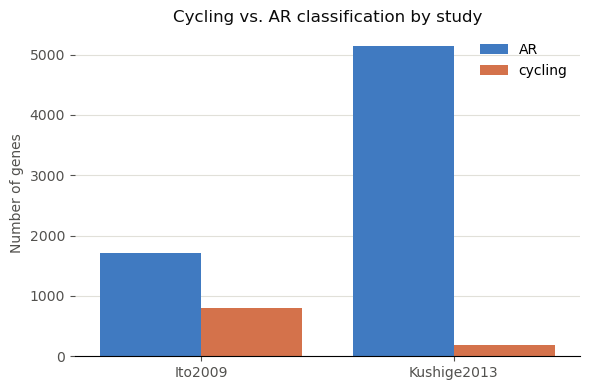

In [192]:
# Grouped bar chart: AR vs. cycling gene counts by study.
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = (
    common_df.groupby(["dataset", "is_cycling_within_study"])
    .size()
    .reset_index(name="count")
)
plot_df["group"] = plot_df["is_cycling_within_study"].map({True: "cycling", False: "AR"})

group_colors = {"AR": "#2a78d6", "cycling": "#eb6834"}

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    data=plot_df, x="dataset", y="count", hue="group", hue_order=["AR", "cycling"],
    palette=group_colors, ax=ax,
)
ax.set_title("Cycling vs. AR classification by study", color="#0b0b0b")
ax.set_ylabel("Number of genes", color="#52514e")
ax.set_xlabel("")
ax.tick_params(colors="#52514e")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
sns.despine(ax=ax, left=True)
ax.legend(title="", frameon=False)
plt.tight_layout()
plt.show()


## Shared-gene overlap between studies

Ito2009 and Kushige2013 use different locus-tag systems, so genes are matched by their shared gene name. The cells below build a per-gene comparison table, summarize cycling agreement as a venn-style contingency count, and visualize it as a heatmap.

In [193]:
# Shared-gene comparison table: one row per gene name present in both studies,
# with each study's cycling classification side by side.

ito_genes = (
    common_df[common_df["dataset"] == "Ito2009"]
    .dropna(subset=["gene_name"])
    .drop_duplicates(subset="gene_name")
    [["gene_name", "cycling_label", "is_cycling_within_study"]]
    .rename(columns={"cycling_label": "cycling_label_ito", "is_cycling_within_study": "is_cycling_ito"})
)

kushige_genes = (
    common_df[common_df["dataset"] == "Kushige2013"]
    .dropna(subset=["gene_name"])
    .drop_duplicates(subset="gene_name")
    [["gene_name", "cycling_label", "is_cycling_within_study"]]
    .rename(columns={"cycling_label": "cycling_label_kushige", "is_cycling_within_study": "is_cycling_kushige"})
)

shared_gene_comparison = ito_genes.merge(kushige_genes, on="gene_name", how="inner").sort_values("gene_name")

print(f"Genes with a shared name in both studies: {len(shared_gene_comparison)}")
shared_gene_comparison.head(20)


Genes with a shared name in both studies: 390


,gene_name,cycling_label_ito,is_cycling_ito,cycling_label_kushige,is_cycling_kushige
353,PgsA,AR,False,AR,False
4,accA,AR,False,AR,False
227,accB,a,True,AR,False
26,accC,AR,False,AR,False
335,accD,AR,False,AR,False
317,ackA,a,True,AR,False
194,ama,a,True,AR,False
155,amt1,a,True,AR,False
176,apcA,AR,False,AR,False
177,apcB,AR,False,a,True


In [194]:
# Venn-style overlap summary: cycling classification agreement among shared genes.

overlap_counts = (
    shared_gene_comparison
    .groupby(["is_cycling_ito", "is_cycling_kushige"])
    .size()
    .reset_index(name="count")
)
overlap_counts["ito"] = overlap_counts["is_cycling_ito"].map({True: "cycling", False: "AR"})
overlap_counts["kushige"] = overlap_counts["is_cycling_kushige"].map({True: "cycling", False: "AR"})
print(overlap_counts[["ito", "kushige", "count"]].to_string(index=False))

both_cycling = shared_gene_comparison[
    shared_gene_comparison["is_cycling_ito"] & shared_gene_comparison["is_cycling_kushige"]
]
print(f"\nGenes classified as cycling in BOTH studies: {len(both_cycling)}")
print(sorted(both_cycling["gene_name"].tolist()))


    ito kushige  count
     AR      AR    236
     AR cycling     31
cycling      AR    107
cycling cycling     16

Genes classified as cycling in BOTH studies: 16
['argG', 'ccmM', 'cpcF', 'gap1', 'gap2', 'glgB', 'glyQ', 'hoxU', 'narM', 'pds', 'por', 'rpaC', 'rpl13', 'rpl16', 'rpl31', 'zwf']


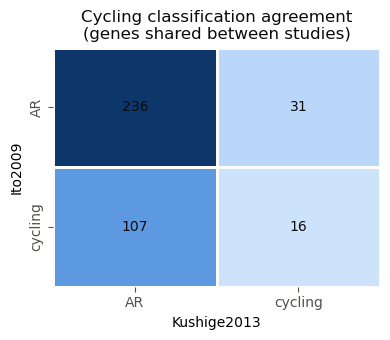

Kushige2013,AR,cycling
Ito2009,,
AR,236,31
cycling,107,16


In [195]:
# Contingency-style heatmap of cycling classification agreement between the two studies.
from matplotlib.colors import LinearSegmentedColormap

blue_sequential = LinearSegmentedColormap.from_list(
    "blue_sequential", ["#cde2fb", "#6da7ec", "#256abf", "#0d366b"]
)

contingency = pd.crosstab(
    shared_gene_comparison["is_cycling_ito"].map({True: "cycling", False: "AR"}),
    shared_gene_comparison["is_cycling_kushige"].map({True: "cycling", False: "AR"}),
)
contingency = contingency.loc[["AR", "cycling"], ["AR", "cycling"]]
contingency.index.name = "Ito2009"
contingency.columns.name = "Kushige2013"

fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(
    contingency, annot=True, fmt="d", cmap=blue_sequential, cbar=False,
    linewidths=2, linecolor="#fcfcfb", annot_kws={"color": "#0b0b0b"}, ax=ax,
)
ax.set_title("Cycling classification agreement\n(genes shared between studies)", color="#0b0b0b")
ax.tick_params(colors="#52514e")
plt.tight_layout()
plt.show()

contingency


In [196]:
# Detailed table of genes classified as cycling in BOTH studies.
# Only 16 genes overlap, so pull in annotation/timing details for a readable reference table.
# Also surface each study's locus tag / gene ID -- gene-name matching can pair unrelated
# genes that happen to share a symbol, so these let you spot-check any pairing (e.g. by
# comparing annotation text, or looking the loci up in KEGG/CyanoBase) the way we did for
# narM (Synpcc7942_0933 vs. alr0614 -- identical annotation text, a good sign of a real match).

ito_details = (
    common_df[common_df["dataset"] == "Ito2009"]
    .dropna(subset=["gene_name"])
    .drop_duplicates(subset="gene_name")
    [["gene_name", "gene_id", "locus_tag", "annotation", "peak_time", "p_value"]]
    .rename(columns={
        "gene_id": "gene_id_ito", "locus_tag": "locus_tag_ito",
        "annotation": "annotation_ito", "peak_time": "peak_time_ito", "p_value": "p_value_ito",
    })
)

kushige_details = (
    common_df[common_df["dataset"] == "Kushige2013"]
    .dropna(subset=["gene_name"])
    .drop_duplicates(subset="gene_name")
    # Kushige2013 has no separate locus_tag column -- its "gene_id" (ORF No., e.g.
    # alr0614) IS the Anabaena locus tag, so surface it under both names for a
    # like-for-like comparison against Ito's locus_tag_ito column.
    .assign(locus_tag=lambda x: x["gene_id"])
    [["gene_name", "gene_id", "locus_tag", "annotation", "category"]]
    .rename(columns={
        "gene_id": "gene_id_kushige", "locus_tag": "locus_tag_kushige",
        "annotation": "annotation_kushige", "category": "category_kushige",
    })
)

both_cycling_table = (
    both_cycling[["gene_name"]]
    .merge(ito_details, on="gene_name", how="left")
    .merge(kushige_details, on="gene_name", how="left")
    .sort_values("gene_name")
    .reset_index(drop=True)
)

print(f"Genes cycling in both studies: {len(both_cycling_table)}")
both_cycling_table[[
    "gene_name", "locus_tag_ito", "locus_tag_kushige",
    "annotation_ito", "annotation_kushige", "peak_time_ito", "category_kushige",
]]


Genes cycling in both studies: 16


,gene_name,locus_tag_ito,locus_tag_kushige,annotation_ito,annotation_kushige,peak_time_ito,category_kushige
0,argG,Synpcc7942_0009,alr4798,argininosuccinate synthetase,argininosuccinate synthase,21.2,Amino acid biosynthesis
1,ccmM,Synpcc7942_1423,all0865,carbon dioxide concentrating mechanism protein...,carbon dioxide concentrating mechanism protein...,20.2,Photosynthesis and respiration
2,cpcF,Synpcc7942_1055,alr0533,phycocyanin alpha subunit phycocyanobilin lyas...,phycocyanin alpha subunit phycocyanobilin lyas...,2.4,Photosynthesis and respiration
3,gap1,Synpcc7942_0245,all2566,glyceraldehyde 3-phosphate dehydrogenase,glyceraldehyde-3-phosphate dehydrogenase,10.6,Energy metabolism
4,gap2,Synpcc7942_1742,all5062,NAD(P)-dependent glyceraldehyde-3-phosphate de...,glyceraldehyde-3-phosphate dehydrogenase,21.4,Photosynthesis and respiration
5,glgB,Synpcc7942_1085,all0713,14-alpha-glucan branching enzyme,"1,4-alpha-glucan branching enzyme",11.4,Central intermediary metabolism
6,glyQ,Synpcc7942_2457,all1985,glycyl-tRNA synthetase alpha chain,glycyl-tRNA synthetase alpha chain,21,Translation
7,hoxU,Synpcc7942_2557,alr0762,NAD-reducing hydrogenase HoxS gamma subunit,hydrogenase chain U,10.4,Other categories
8,narM,Synpcc7942_0933,alr0614,Nitrate reductase-related protein,Nitrate reductase-related protein,20,Hypothetical
9,pds,Synpcc7942_1983,alr1832,phytoene dehydrogenase (phytoene desaturase),phytoene desaturase,17.4,"Biosynthesis of cofactors, prosthetic groups, ..."


### Ortholog-pairing confidence

Gene-name matching (like `narM`) can pair genes that share a symbol but aren't actually orthologs. A real BLASTp/KEGG-KO check needs external sequence/API access this notebook doesn't have, so as a local proxy: score how closely each pair's free-text annotation agrees. High agreement on a specific description (like `narM`'s identical "Nitrate reductase-related protein") is decent evidence both annotation pipelines converged on the same gene family. Low agreement is a flag to verify manually via the locus tags above (e.g. in KEGG or CyanoBase) before trusting that gene's comparison.

gene_name   locus_tag_ito locus_tag_kushige  similarity confidence
     hoxU Synpcc7942_2557           alr0762    0.483871        Low
      pds Synpcc7942_1983           alr1832    0.603175     Medium
     ccmM Synpcc7942_1423           all0865    0.713287     Medium
     gap2 Synpcc7942_1742           all5062    0.824742     Medium
      zwf Synpcc7942_2334           all4019    0.941176       High
     argG Synpcc7942_0009           alr4798    0.962963       High
     gap1 Synpcc7942_0245           all2566    0.975000       High
     glgB Synpcc7942_1085           all0713    0.984615       High
     cpcF Synpcc7942_1055           alr0533    1.000000       High
     glyQ Synpcc7942_2457           all1985    1.000000       High
     narM Synpcc7942_0933           alr0614    1.000000       High
      por Synpcc7942_2503           all1743    1.000000       High
     rpaC Synpcc7942_1987           all2971    1.000000       High
    rpl13 Synpcc7942_2206           all4188    1.000000       

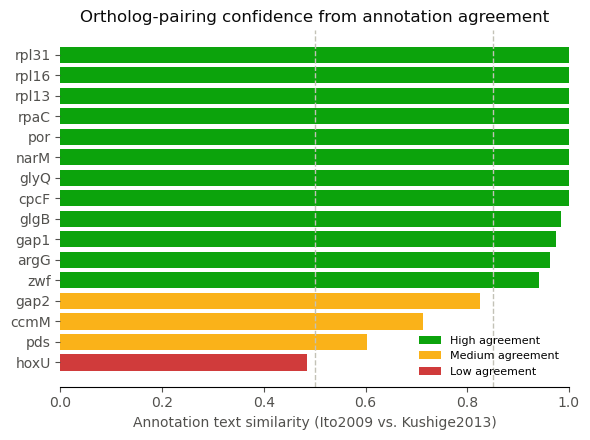

In [197]:
import difflib
import numpy as np
from matplotlib.patches import Patch

GENERIC_ANNOTATIONS = {"hypothetical protein", "unknown protein", "conserved hypothetical protein", "putative protein"}

def normalize_annotation(text):
    return " ".join(str(text).lower().split())

def annotation_similarity(a, b):
    return difflib.SequenceMatcher(None, normalize_annotation(a), normalize_annotation(b)).ratio()

ortholog_confidence = both_cycling_table[
    ["gene_name", "locus_tag_ito", "locus_tag_kushige", "annotation_ito", "annotation_kushige"]
].copy()
ortholog_confidence["similarity"] = ortholog_confidence.apply(
    lambda r: annotation_similarity(r["annotation_ito"], r["annotation_kushige"]), axis=1
)
ortholog_confidence["is_generic"] = ortholog_confidence["annotation_ito"].apply(
    lambda a: normalize_annotation(a) in GENERIC_ANNOTATIONS
)
ortholog_confidence["confidence"] = np.select(
    [ortholog_confidence["similarity"] >= 0.85, ortholog_confidence["similarity"] >= 0.5],
    ["High", "Medium"],
    default="Low",
)
ortholog_confidence = ortholog_confidence.sort_values("similarity")

print(ortholog_confidence[[
    "gene_name", "locus_tag_ito", "locus_tag_kushige", "similarity", "confidence",
]].to_string(index=False))

generic_genes = ortholog_confidence.loc[ortholog_confidence["is_generic"], "gene_name"].tolist()
if generic_genes:
    print(f"\nNote: {generic_genes} matched on a generic annotation (e.g. 'hypothetical protein') --")
    print("that scores as high textual similarity but is weak evidence of true orthology on its own,")
    print("since an uninformative description matching is not very specific.")

# Status-style coloring: high agreement = good, low agreement = needs manual review.
status_colors = {"High": "#0ca30c", "Medium": "#fab219", "Low": "#d03b3b"}
fig, ax = plt.subplots(figsize=(6, 4.5))
bar_colors = [status_colors[c] for c in ortholog_confidence["confidence"]]
ax.barh(ortholog_confidence["gene_name"], ortholog_confidence["similarity"], color=bar_colors)
ax.set_xlim(0, 1)
ax.axvline(0.85, color="#c3c2b7", linewidth=1, linestyle="--")
ax.axvline(0.5, color="#c3c2b7", linewidth=1, linestyle="--")
ax.set_xlabel("Annotation text similarity (Ito2009 vs. Kushige2013)", color="#52514e")
ax.set_title("Ortholog-pairing confidence from annotation agreement", color="#0b0b0b")
ax.tick_params(colors="#52514e")
sns.despine(ax=ax, left=True)
ax.legend(
    handles=[Patch(facecolor=c, label=f"{t} agreement") for t, c in status_colors.items()],
    frameon=False, loc="lower right", fontsize=8,
)
plt.tight_layout()
plt.show()


**On the Medium/Low-agreement genes:** `pds`, `ccmM`, and `gap2` score below "High" only because one study wrote a longer descriptive phrase and the other a shorter one for the same enzyme (e.g. Ito's own annotation for `pds` is *"phytoene dehydrogenase (phytoene desaturase)"* — it names the Kushige synonym itself, in parentheses). That's a scoring-metric artifact, not a real identity concern.

`hoxU` (similarity 0.48, "Low") is the one worth a closer look, and even that turns out to be benign: Ito's own gene-symbol column says `hoxU`, but its free-text annotation says *"HoxS gamma subunit"* — "HoxS" isn't a subunit in the canonical cyanobacterial Hox operon (HoxE/F/U/Y/H), so this looks like a typo internal to Ito2009 rather than a true mismatch with Kushige's `hoxU`. It's also not consequential either way: `hoxU`'s Ito-vs-Kushige phase difference is only ~1.6h, far from the outliers on the phase-offset chart, so even in the worst case this pairing isn't driving any of the conclusions above.

In [198]:
# Kushige2013 doesn't publish a peak-time column like Ito2009 does -- only raw
# expression time series under nitrogen-replete conditions (N+, two replicates,
# sampled every 4h from LL4 to LL48). That window spans TWO ~24h cycles, so a
# raw elapsed-time max (e.g. LL32) doesn't respect the circadian period -- it can
# land in cycle 2 just from overall drift in the signal, not from phase.
#
# Fix: fold both cycles onto a single 24h phase (LL28->4, LL32->8, ..., LL48->0),
# average all values landing on the same phase (2 replicates x 2 cycles = up to
# 4 values per phase point), and take the argmax of that averaged phase profile.

ll_timepoints = [4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48]
phases = sorted({t % 24 for t in ll_timepoints})  # [0, 4, 8, 12, 16, 20]

def approx_peak_time_kushige(gene_name):
    match = kushige_df[kushige_df["Gene name"] == gene_name]
    if match.empty:
        return pd.NA
    row = match.iloc[0]
    values_by_phase = {p: [] for p in phases}
    for t in ll_timepoints:
        phase = t % 24
        values_by_phase[phase].append(row[f"N+_1st_LL{t}"])
        values_by_phase[phase].append(row[f"N+_2nd_LL{t}"])
    avg_by_phase = {p: sum(v) / len(v) for p, v in values_by_phase.items()}
    return max(avg_by_phase, key=avg_by_phase.get)

both_cycling_table["peak_time_kushige"] = both_cycling_table["gene_name"].apply(approx_peak_time_kushige)

both_cycling_table[["gene_name", "peak_time_ito", "peak_time_kushige", "annotation_ito"]]


,gene_name,peak_time_ito,peak_time_kushige,annotation_ito
0,argG,21.2,0,argininosuccinate synthetase
1,ccmM,20.2,0,carbon dioxide concentrating mechanism protein...
2,cpcF,2.4,8,phycocyanin alpha subunit phycocyanobilin lyas...
3,gap1,10.6,16,glyceraldehyde 3-phosphate dehydrogenase
4,gap2,21.4,4,NAD(P)-dependent glyceraldehyde-3-phosphate de...
5,glgB,11.4,8,14-alpha-glucan branching enzyme
6,glyQ,21,0,glycyl-tRNA synthetase alpha chain
7,hoxU,10.4,12,NAD-reducing hydrogenase HoxS gamma subunit
8,narM,20,8,Nitrate reductase-related protein
9,pds,17.4,4,phytoene dehydrogenase (phytoene desaturase)


gene_name  peak_time_ito  peak_time_kushige  signed_diff_hours
     narM           20.0                8.0              -12.0
      pds           17.4                4.0              -10.6
     gap2           21.4                4.0               -6.6
      por            1.4                8.0               -6.6
    rpl31           14.0               20.0               -6.0
     cpcF            2.4                8.0               -5.6
    rpl13           14.4               20.0               -5.6
     gap1           10.6               16.0               -5.4
      zwf           10.8               16.0               -5.2
    rpl16           15.0               20.0               -5.0
     ccmM           20.2                0.0               -3.8
     glyQ           21.0                0.0               -3.0
     argG           21.2                0.0               -2.8
     hoxU           10.4               12.0               -1.6
     rpaC            8.8                8.0            

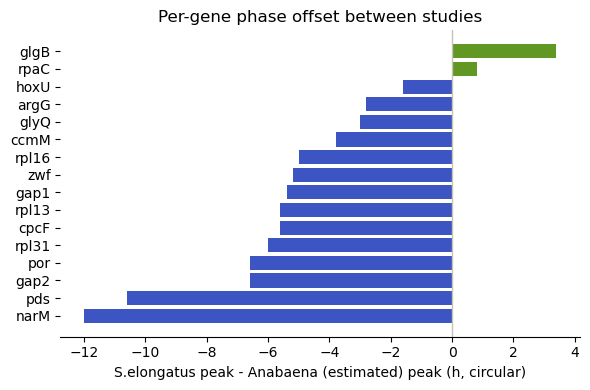

In [199]:
# Is the Ito vs. Kushige peak-time mismatch a systematic offset (methodological
# artifact -- different zero-time reference, coarse binning) or gene-specific
# (a real phase shift under nitrogen status)? Compute the circular phase
# difference for each of the 16 shared cycling genes and look at the shape of
# the distribution: a tight cluster around one value points to a systematic
# offset; a wide, inconsistent spread points to gene-specific rephasing.
import numpy as np

def circular_diff_signed(a, b, period=24):
    # Wrap to (-period/2, period/2] so e.g. 23h vs 1h reads as a 2h difference, not 22h.
    return ((a - b + period / 2) % period) - period / 2

phase_diff = both_cycling_table.dropna(subset=["peak_time_ito", "peak_time_kushige"]).copy()
phase_diff["peak_time_ito"] = phase_diff["peak_time_ito"].astype(float)
phase_diff["peak_time_kushige"] = phase_diff["peak_time_kushige"].astype(float)
phase_diff["signed_diff_hours"] = circular_diff_signed(phase_diff["peak_time_ito"], phase_diff["peak_time_kushige"])
phase_diff["abs_diff_hours"] = phase_diff["signed_diff_hours"].abs()
phase_diff = phase_diff.sort_values("signed_diff_hours")

print(phase_diff[["gene_name", "peak_time_ito", "peak_time_kushige", "signed_diff_hours"]].to_string(index=False))
print(f"\nMedian |phase difference|: {phase_diff['abs_diff_hours'].median():.1f}h")
print(f"Mean signed difference: {phase_diff['signed_diff_hours'].mean():+.1f}h  (std {phase_diff['signed_diff_hours'].std():.1f}h)")
print("Tight cluster near one value -> likely a systematic zero-time/binning offset.")
print("Wide, inconsistent spread -> more consistent with gene-specific rephasing.")

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#619723" if v >= 0 else "#3d55c2" for v in phase_diff["signed_diff_hours"]]
ax.barh(phase_diff["gene_name"], phase_diff["signed_diff_hours"], color=colors)
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.set_xlabel("S.elongatus peak - Anabaena (estimated) peak (h, circular)", color="#000000")
ax.set_title("Per-gene phase offset between studies", color="#000000")
ax.tick_params(colors="#000000")
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()


**Per-gene phase offset between Ito et al. (2009) and Kushige et al. (2013) for genes classified as cycling in both studies.** Ito et al. (2009) charted cyclic genes in S.Elongatus PCC 7942 and Kushige et al. (2013) in Anabaena sp. PCC 7120. Bars show the circular difference in reported peak expression time (Ito et al.(2009) peak − Kushige et al. (2013) peak, wrapped to ±12 h) for the 16 genes independently classified as cycling in both datasets. Most genes (14/16) show the same-direction offset, consistent with a systematic difference between studies — likely reflecting differing zero-time references and/or growth-correlated drift in the Kushige2013 time series, since the shift is comparable across genes in the same functional class (e.g., ribosomal proteins rpl13, rpl16, rpl31, glyQ). Two genes deviate from this trend: narM (nitrate reductase-related) shows a near-antiphase shift, and glgB (glycogen branching enzyme) shifts in the opposite direction, potentially reflecting genuine nitrogen-status-dependent rephasing rather than the systematic study-to-study offset. n = 16; interpret individual gene values cautiously given the coarse (4 h) resolution and limited replication of the Kushige2013 time-course.

gene_name cycling_label_nplus cycling_label_nminus  nitrogen_dependent peak_time_ito  peak_time_kushige  peak_time_nminus
     argG                   c                    a               False          21.2                  0                20
     ccmM                   c                   AR                True          20.2                  0                20
     cpcF                   a                    b               False           2.4                  8                 8
     gap1                   b                    a               False          10.6                 16                12
     gap2                   b                    b               False          21.4                  4                 4
     glgB                   a                    b               False          11.4                  8                 8
     glyQ                   c                   AR                True            21                  0                20
     hoxU               

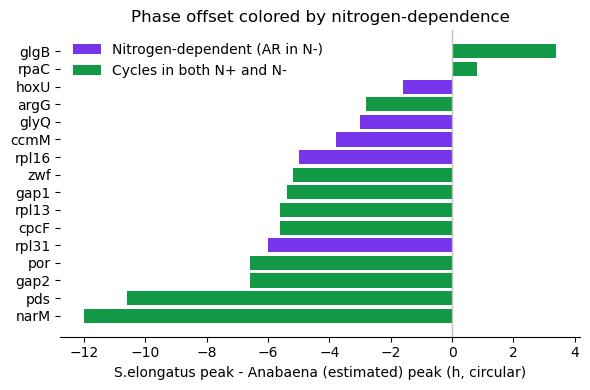

In [200]:
# Anchor: Kushige2013 is Anabaena PCC 7120 (nitrogen-fixing, forms heterocysts under
# nitrogen step-down), not the same species as Ito2009's Synechococcus elongatus PCC
# 7942 (non-diazotrophic, no differentiation). So Kushige's N- condition isn't just
# "stressed cells" -- it triggers a developmental program 7942 cannot undergo at all.
#
# Compare N+ (nitrogen-replete) vs. N- (nitrogen step-down) cycling status *within*
# Kushige2013 for the 16 shared genes. Genes that stay rhythmic in both conditions are
# better candidates for core clock output conserved with 7942; genes that go arrhythmic
# in N- are more likely tied to the heterocyst-differentiation program specifically,
# and a mismatch with Ito2009 for those genes isn't surprising or artifactual at all.

nitrogen_labels = (
    kushige_df[kushige_df["Gene name"].isin(both_cycling_table["gene_name"])]
    [["Gene name", "Cycling property (N+, n=2)*", "Cycling property (N-, n=1)**"]]
    .rename(columns={
        "Gene name": "gene_name",
        "Cycling property (N+, n=2)*": "cycling_label_nplus",
        "Cycling property (N-, n=1)**": "cycling_label_nminus",
    })
)
nitrogen_labels["is_cycling_nplus"] = nitrogen_labels["cycling_label_nplus"].astype(str).str.upper() != "AR"
nitrogen_labels["is_cycling_nminus"] = nitrogen_labels["cycling_label_nminus"].astype(str).str.upper() != "AR"

def approx_peak_time_nminus(gene_name):
    # N- has only one replicate (n=1), still spans two folded 24h cycles (LL4-LL48).
    match = kushige_df[kushige_df["Gene name"] == gene_name]
    if match.empty:
        return pd.NA
    row = match.iloc[0]
    values_by_phase = {p: [] for p in phases}
    for t in ll_timepoints:
        values_by_phase[t % 24].append(row[f"N-_1st_LL{t}"])
    avg_by_phase = {p: sum(v) / len(v) for p, v in values_by_phase.items()}
    return max(avg_by_phase, key=avg_by_phase.get)

nitrogen_labels["peak_time_nminus"] = nitrogen_labels["gene_name"].apply(approx_peak_time_nminus)

nitrogen_comparison = both_cycling_table[["gene_name", "peak_time_ito", "peak_time_kushige"]].merge(
    nitrogen_labels, on="gene_name", how="left"
)
nitrogen_comparison["nitrogen_dependent"] = (
    nitrogen_comparison["is_cycling_nplus"] & ~nitrogen_comparison["is_cycling_nminus"]
)

print(nitrogen_comparison[[
    "gene_name", "cycling_label_nplus", "cycling_label_nminus", "nitrogen_dependent",
    "peak_time_ito", "peak_time_kushige", "peak_time_nminus",
]].to_string(index=False))

n_dependent = nitrogen_comparison.loc[nitrogen_comparison["nitrogen_dependent"], "gene_name"].tolist()
n_independent = nitrogen_comparison.loc[~nitrogen_comparison["nitrogen_dependent"], "gene_name"].tolist()
print(f"\nNitrogen-dependent (cycling in N+, arrhythmic in N-): {len(n_dependent)} -> {n_dependent}")
print(f"Nitrogen-independent (cycling in both N+ and N-): {len(n_independent)} -> {n_independent}")

# Overlay onto the phase-offset chart: are the biggest Ito-vs-Kushige mismatches the
# nitrogen-dependent genes, or do they cut across both groups?
from matplotlib.patches import Patch

plot_data = phase_diff.merge(nitrogen_comparison[["gene_name", "nitrogen_dependent"]], on="gene_name", how="left")
bar_colors = ["#7734eb" if v else "#119945" for v in plot_data["nitrogen_dependent"]]

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(plot_data["gene_name"], plot_data["signed_diff_hours"], color=bar_colors)
ax.axvline(0, color="#c3c2b7", linewidth=1)
ax.set_xlabel("S.elongatus peak - Anabaena (estimated) peak (h, circular)", color="#000000")
ax.set_title("Phase offset colored by nitrogen-dependence", color="#000000")
ax.tick_params(colors="#000000")
sns.despine(ax=ax, left=True)
ax.legend(
    handles=[
        Patch(facecolor="#7734eb", label="Nitrogen-dependent (AR in N-)"),
        Patch(facecolor="#119945", label="Cycles in both N+ and N-"),
    ],
    frameon=False, loc="upper left",
)
plt.tight_layout()
plt.show()


### Digging into narM: is the antiphase result an artifact of a weak signal?

`narM` is the strongest identity match (identical annotation text, `narM`↔`narM`) but the largest phase mismatch of all 16 genes -- Ito2009 reports its peak in daylight hours (~20h), Kushige2013 in the opposite part of the cycle. A large phase mismatch driven by a weak, noisy rhythm in one dataset would be much less convincing than the same mismatch riding on top of two strong, confidently-timed rhythms. Ito2009 already reports a per-gene amplitude; Kushige2013 doesn't, so approximate one from the raw N+/N- time series the same way peak time was approximated, and compare.

Ito2009 (7942):    peak=20h  amplitude*=0.117  (cosinor-style relative amplitude)
Kushige2013 (Anabaena) N+:  relative amplitude (max-min)/mean = 0.99  (627-1903 raw units)
Kushige2013 (Anabaena) N-:  relative amplitude (max-min)/mean = 0.50  (561-899 raw units)

Ito's amplitude is modest but real (this gene was still called 'cycling', p=0.017).
Kushige's N+ swing is large -- nearly 3x peak-to-trough -- so the antiphase result isn't
coming from a flat/noisy signal quietly picking a random argmax; Anabaena narM has a
genuinely strong, confidently-timed rhythm, just timed very differently from 7942's.

NOTE: the S. elongatus curve below is a RECONSTRUCTION (idealized cosine from Ito's
reported peak time + amplitude), not real time-series data -- Ito2009 doesn't publish one.


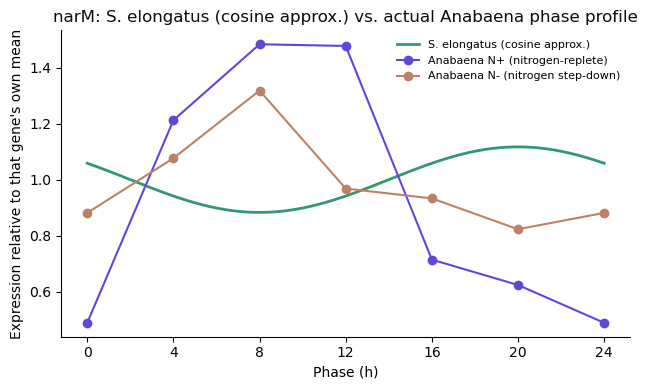

In [201]:
gene = "narM"
ito_row = ito_df[ito_df["Gene Name"] == gene].iloc[0]
kush_row = kushige_df[kushige_df["Gene name"] == gene].iloc[0]

def phase_profile(row, condition):
    # condition: "N+" (2 replicates x 2 cycles) or "N-" (1 replicate x 2 cycles)
    by_phase = {p: [] for p in phases}
    for t in ll_timepoints:
        p = t % 24
        if condition == "N+":
            by_phase[p].append(row[f"N+_1st_LL{t}"])
            by_phase[p].append(row[f"N+_2nd_LL{t}"])
        else:
            by_phase[p].append(row[f"N-_1st_LL{t}"])
    return {p: sum(v) / len(v) for p, v in by_phase.items()}

nplus_profile = phase_profile(kush_row, "N+")
nminus_profile = phase_profile(kush_row, "N-")

def relative_amplitude(profile):
    vals = list(profile.values())
    mean_v = sum(vals) / len(vals)
    return (max(vals) - min(vals)) / mean_v

ito_amplitude = ito_row["Amplitude*"]
ito_peak = ito_row["Peak time*"]
nplus_amp = relative_amplitude(nplus_profile)
nminus_amp = relative_amplitude(nminus_profile)

print(f"Ito2009 (7942):    peak={ito_peak}h  amplitude*={ito_amplitude:.3f}  (cosinor-style relative amplitude)")
print(f"Kushige2013 (Anabaena) N+:  relative amplitude (max-min)/mean = {nplus_amp:.2f}  ({min(nplus_profile.values()):.0f}-{max(nplus_profile.values()):.0f} raw units)")
print(f"Kushige2013 (Anabaena) N-:  relative amplitude (max-min)/mean = {nminus_amp:.2f}  ({min(nminus_profile.values()):.0f}-{max(nminus_profile.values()):.0f} raw units)")
print()
print("Ito's amplitude is modest but real (this gene was still called 'cycling', p=0.017).")
print("Kushige's N+ swing is large -- nearly 3x peak-to-trough -- so the antiphase result isn't")
print("coming from a flat/noisy signal quietly picking a random argmax; Anabaena narM has a")
print("genuinely strong, confidently-timed rhythm, just timed very differently from 7942's.")

# Ito2009's spreadsheet has no raw time series for narM -- only the fitted peak time and
# amplitude from their own cosinor analysis. To show it on the same axes as Anabaena's real
# data, index everything to "fraction of that gene's own mean" (rather than a dual y-axis,
# which would make two different-scale measures look artificially comparable) and
# reconstruct an idealized cosine curve from Ito's reported peak + amplitude. This assumes
# Ito's "Amplitude*" is a fractional/relative amplitude around the mean, matching how the
# Anabaena relative amplitude above is defined -- flagged here since that assumption isn't
# independently confirmed from the spreadsheet alone.
print()
print("NOTE: the S. elongatus curve below is a RECONSTRUCTION (idealized cosine from Ito's")
print("reported peak time + amplitude), not real time-series data -- Ito2009 doesn't publish one.")

nplus_mean = sum(nplus_profile.values()) / len(nplus_profile)
nminus_mean = sum(nminus_profile.values()) / len(nminus_profile)
nplus_rel = {p: v / nplus_mean for p, v in nplus_profile.items()}
nminus_rel = {p: v / nminus_mean for p, v in nminus_profile.items()}

t_dense = np.linspace(0, 24, 200)
ito_rel_curve = 1 + ito_amplitude * np.cos(2 * np.pi * (t_dense - ito_peak) / 24)

plot_phases = phases + [24]
nplus_line = [nplus_rel[p % 24] for p in plot_phases]
nminus_line = [nminus_rel[p % 24] for p in plot_phases]

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(t_dense, ito_rel_curve, color="#339771", linewidth=2, linestyle="-",
        label="S. elongatus (cosine approx.)")
ax.plot(plot_phases, nplus_line, marker="o", color="#5e48dc", label="Anabaena N+ (nitrogen-replete)")
ax.plot(plot_phases, nminus_line, marker="o", color="#bc8265", label="Anabaena N- (nitrogen step-down)")
ax.set_xticks(plot_phases)
ax.set_xlabel("Phase (h)", color="#000000")
ax.set_ylabel("Expression relative to that gene's own mean", color="#000000")
ax.set_title("narM: S. elongatus (cosine approx.) vs. actual Anabaena phase profile", color="#0b0b0b")
ax.tick_params(colors="#000000")
sns.despine(ax=ax)
ax.legend(frameon=False, loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


In [208]:
# This cell intentionally keeps the save helper separate from the analysis cells.
# Run it only when you want to commit and push the notebook state.

#save_and_push(config=current_nb)
current_hurdles = {
    "repo_path": str(repo_path),
    "message": "Update hurdles",
    "files": ["hurdles.md"],
    }
# save_and_push(config=current_hurdles)

save_and_push(config=current_nb)
    

{'committed': True,
 'pushed': True,
 'branch': 'master',
 'message': 'Update notebook analysis'}